In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, generator):
    reconstruction_errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
    return np.array(reconstruction_errors)

# Berechnung der Rekonstruktionsfehler für eine begrenzte Anzahl von Testdaten
def calculate_reconstruction_error_limited(model, generator, limit=10000):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        if count >= limit:
            break
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
        count += len(X)
    return np.array(reconstruction_errors[:limit])

# Rekonstruktionsfehler für Nutzer 1
user_1_id = user_ids[0]  # Assuming user 1 is the first user in the list
_, _, test_generator_user_1 = user_generators[user_1_id]
reconstruction_error_user_1 = calculate_reconstruction_error_limited(autoencoder, test_generator_user_1, limit=10000)

# Erstellen von 5 Diagrammen mit Nutzer 1 und einem zufälligen anderen Nutzer
for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=10000)
    
    plt.figure(figsize=(12, 8))
    sns.histplot(reconstruction_error_user_1, bins=50, kde=True, color='purple', label=f'Test {user_1_id}')
    sns.histplot(reconstruction_error_random_user, bins=50, kde=True, label=f'Test {random_user_id}')
    
    plt.title(f'Rekonstruktionsfehler für Nutzer 1 und zufälligen Nutzer {i+1}')
    plt.xlabel('Rekonstruktionsfehler')
    plt.ylabel('Häufigkeit')
    plt.legend()
    plt.show()

# Bewertung der Modellleistung
mean_user_1_error = np.mean(reconstruction_error_user_1)
mean_random_user_errors = []

for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=10000)
    mean_random_user_errors.append(np.mean(reconstruction_error_random_user))

mean_random_user_error = np.mean(mean_random_user_errors)

print("\nBewertung der Modellleistung:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1): {mean_user_1_error}")
print(f"Durchschnittlicher Rekonstruktionsfehler (zufällige Nutzer): {mean_random_user_error}")

# Adaptive Erklärung der Ergebnisse
print("\nAdaptive Erklärung der Ergebnisse:")
if mean_user_1_error < min(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 gut und unterscheidet ihn von anderen Nutzern.")
elif mean_user_1_error < np.mean(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 einigermaßen gut, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Test mit 10.000 zufälligen Samples pro Nutzer
random_samples = []
random_labels = []

for _ in range(10000 * len(user_ids)):
    random_user_id = random.choice(user_ids)
    _, _, test_generator_random_user = user_generators[random_user_id]
    random_sample = next(iter(test_generator_random_user))[0][0]  # Nimm das erste Sample aus dem Generator
    random_samples.append(random_sample)
    random_labels.append(1 if random_user_id == user_1_id else 0)

random_samples = np.array(random_samples)
reconstruction_errors_random_samples = np.mean(np.square(random_samples - autoencoder.predict(random_samples)), axis=1)

# Debugging-Ausgaben
print(f"Anzahl der zufälligen Samples: {len(random_samples)}")
print(f"Rekonstruktionsfehler für zufällige Samples: {reconstruction_errors_random_samples}")

# Grafische Darstellung der Rekonstruktionsfehler für zufällige Samples
plt.figure(figsize=(12, 8))
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 1], bins=50, kde=True, color='purple', label='Nutzer 1')
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 0], bins=50, kde=True, color='blue', label='Andere Nutzer')

plt.title('Rekonstruktionsfehler für zufällige Samples')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

# Bewertung der Modellleistung für zufällige Samples
mean_error_user_1_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 1])
mean_error_other_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 0])

print("\nBewertung der Modellleistung für zufällige Samples:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1 Samples): {mean_error_user_1_samples}")
print(f"Durchschnittlicher Rekonstruktionsfehler (Andere Nutzer Samples): {mean_error_other_samples}")

# Adaptive Erklärung der Ergebnisse für zufällige Samples
print("\nAdaptive Erklärung der Ergebnisse für zufällige Samples:")
if mean_error_user_1_samples < mean_error_other_samples:
    print("Das Modell erkennt zufällige Samples von Nutzer 1 gut und unterscheidet sie von anderen Nutzern.")
else:
    print("Das Modell hat Schwierigkeiten, zufällige Samples von Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Entscheidung, ob ein Sample als Nutzer 1 erkannt wird
threshold = (mean_error_user_1_samples + mean_error_other_samples) / 2
predictions = reconstruction_errors_random_samples < threshold

# Bewertung der Vorhersagen
true_positives = np.sum((predictions == 1) & (np.array(random_labels) == 1))
true_negatives = np.sum((predictions == 0) & (np.array(random_labels) == 0))
false_positives = np.sum((predictions == 1) & (np.array(random_labels) == 0))
false_negatives = np.sum((predictions == 0) & (np.array(random_labels) == 1))

print("\nVorhersageergebnisse:")
print(f"True Positives: {true_positives}")
print(f"True Negatives: {true_negatives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")

accuracy = (true_positives + true_negatives) / len(predictions)
print(f"Genauigkeit: {accuracy}")

# Adaptive Erklärung der Vorhersageergebnisse
print("\nAdaptive Erklärung der Vorhersageergebnisse:")
if accuracy > 0.8:
    print("Das Modell kann Nutzer 1 gut erkennen.")
elif accuracy > 0.6:
    print("Das Modell kann Nutzer 1 einigermaßen gut erkennen, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, Nutzer 1 zu erkennen. Eine weitere Optimierung ist erforderlich.")

In [ ]:
import os
import pandas as pd
import pymongo
import matplotlib.pyplot as plt
import seaborn as sns
import base64
from io import BytesIO
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [4]:
# Verbindung zur Datenbank herstellen und Daten laden
def load_data():
    # Verbindung zur Datenbank herstellen
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()

    # Daten aus der 'canvassamples'-Collection laden
    canvassamples_collection = db['canvassamples']
    canvassamples_cursor = canvassamples_collection.find()
    canvassamples_data = list(canvassamples_cursor)
    canvassamples_df = pd.DataFrame(canvassamples_data)

    # Daten aus der 'fingerprints'-Collection laden
    fingerprints_collection = db['fingerprints']
    fingerprints_cursor = fingerprints_collection.find()
    fingerprints_data = list(fingerprints_cursor)
    fingerprints_df = pd.DataFrame(fingerprints_data)

    return canvassamples_df, fingerprints_df

# Daten laden
canvassamples_df, fingerprints_df = load_data()

In [ ]:
# Daten zusammenführen
merged_df = pd.merge(canvassamples_df, fingerprints_df, left_on='fingerprintId', right_on='_id', suffixes=('_sample', '_fingerprint'))

# Benutzer-IDs extrahieren
user_ids = merged_df['username'].unique()

# DataFrames für jeden Benutzer erstellen
user_dfs = {user_id: merged_df[merged_df['username'] == user_id] for user_id in user_ids}

# Beispielhafte Anzeige der ersten 5 Zeilen für jeden Benutzer
for user_id, df in user_dfs.items():
    print(f"Erste 5 Zeilen für Benutzer {user_id}:")
    display(df.head())

In [6]:
import numpy as np

def preprocess_samples(samples, target_length):
    processed_samples = []
    for sample in samples:
        if len(sample) > target_length:
            processed_samples.append(sample[:target_length])
        else:
            processed_samples.append(np.pad(sample, (0, target_length - len(sample)), 'constant'))
    return np.array(processed_samples)

In [7]:
import base64
from sklearn.model_selection import train_test_split

def split_data(df, target_length):
    # Decode base64 and convert to numpy arrays
    decoded_samples = [base64.b64decode(sample) for sample in df['sampleData']]
    numpy_samples = [np.frombuffer(x, dtype=np.uint8) for x in decoded_samples]
    
    # Preprocess samples to ensure consistent length
    processed_samples = preprocess_samples(numpy_samples, target_length)
    
    # Normalize the data
    processed_samples = processed_samples / 255.0
    
    # Split the data
    X_train, X_temp = train_test_split(processed_samples, test_size=0.3, random_state=42)
    X_val, X_test = train_test_split(X_temp, test_size=0.33, random_state=42)  # 0.33 * 0.3 ≈ 0.1
    return X_train, X_val, X_test

In [8]:
import base64
import numpy as np

# Funktion zur Berechnung der Länge eines dekodierten Samples
def decoded_length(sample):
    return len(base64.b64decode(sample))

# Berechnung der Länge der dekodierten Samples
lengths = np.array([decoded_length(sample) for sample in merged_df['sampleData']])

# Bestimmen der maximalen Länge
max_length = lengths.max()

print(f"Maximale Länge der Samples: {max_length}")

Maximale Länge der Samples: 9621


In [9]:
import base64
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence

def process_sample(base64_str, target_length):
    decoded = base64.b64decode(base64_str)
    numpy_sample = np.frombuffer(decoded, dtype=np.uint8)
    if len(numpy_sample) > target_length:
        numpy_sample = numpy_sample[:target_length]
    else:
        numpy_sample = np.pad(numpy_sample, (0, target_length - len(numpy_sample)), 'constant')
    numpy_sample = numpy_sample / 255.0
    return numpy_sample

def split_data_indices(df):
    if len(df) < 3:
        raise ValueError("Nicht genügend Samples zum Aufteilen.")
    indices = df.index.values
    X_train_indices, X_temp_indices = train_test_split(indices, test_size=0.3, random_state=42)
    X_val_indices, X_test_indices = train_test_split(X_temp_indices, test_size=0.3333, random_state=42)
    return X_train_indices, X_val_indices, X_test_indices

class DataGenerator(Sequence):
    def __init__(self, df, indices, target_length, batch_size=32):
        self.df = df
        self.indices = indices
        self.target_length = target_length
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_samples = [process_sample(self.df.at[i, 'sampleData'], self.target_length) for i in batch_indices]
        batch_samples = np.array(batch_samples)
        return batch_samples, batch_samples  # Input und Output sind gleich für Autoencoder

max_length = merged_df['sampleData'].apply(decoded_length).max()
print(f"Maximale Länge der Samples: {max_length}")

user_generators = {}
for user_id, df in user_dfs.items():
    print(f"Verarbeite Benutzer {user_id}...")
    try:
        X_train_indices, X_val_indices, X_test_indices = split_data_indices(df)
        train_generator = DataGenerator(df, X_train_indices, max_length, batch_size=32)
        val_generator = DataGenerator(df, X_val_indices, max_length, batch_size=32)
        test_generator = DataGenerator(df, X_test_indices, max_length, batch_size=32)
        user_generators[user_id] = (train_generator, val_generator, test_generator)
        print(f"Datenaufteilung für Benutzer {user_id} abgeschlossen.")
    except Exception as e:
        print(f"Fehler bei der Datenaufteilung für Benutzer {user_id}: {e}")
print("Datenaufteilung für alle Benutzer abgeschlossen.")

Maximale Länge der Samples: 9621
Verarbeite Benutzer benutzername_1...
Datenaufteilung für Benutzer benutzername_1 abgeschlossen.
Verarbeite Benutzer benutzername_3...
Datenaufteilung für Benutzer benutzername_3 abgeschlossen.
Verarbeite Benutzer benutzername_4...
Datenaufteilung für Benutzer benutzername_4 abgeschlossen.
Verarbeite Benutzer benutzername_5...
Datenaufteilung für Benutzer benutzername_5 abgeschlossen.
Verarbeite Benutzer benutzername_6...
Datenaufteilung für Benutzer benutzername_6 abgeschlossen.
Verarbeite Benutzer benutzername_7...
Datenaufteilung für Benutzer benutzername_7 abgeschlossen.
Verarbeite Benutzer benutzername_8...
Datenaufteilung für Benutzer benutzername_8 abgeschlossen.
Verarbeite Benutzer benutzername_9...
Datenaufteilung für Benutzer benutzername_9 abgeschlossen.
Verarbeite Benutzer benutzername_10...
Datenaufteilung für Benutzer benutzername_10 abgeschlossen.
Verarbeite Benutzer benutzername_11...
Datenaufteilung für Benutzer benutzername_11 abgeschl

In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# Beispielhafter Benutzer
user_id = next(iter(user_generators))
train_generator, val_generator, test_generator = user_generators[user_id]

# Autoencoder-Modell definieren
input_dim = max_length
encoding_dim = 32

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation="relu")(input_layer)
decoder = Dense(input_dim, activation="sigmoid")(encoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)

# Modell kompilieren
autoencoder.compile(optimizer=Adam(), loss='mse')

# Modell trainieren
history = autoencoder.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator
)

Epoch 1/50


2025-01-09 15:51:55.791690: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-09 15:51:55.820366: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-09 15:51:55.820668: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

2188/2188 [==============================] - 9s 4ms/step - loss: 0.0573 - val_loss: 0.0561
Epoch 2/50
2188/2188 [==============================] - 8s 4ms/step - loss: 0.0559 - val_loss: 0.0558
Epoch 3/50
2188/2188 [==============================] - 8s 4ms/step - loss: 0.0558 - val_loss: 0.0559
Epoch 4/50
2188/2188 [==============================] - 8s 4ms/step - loss: 0.0557 - val_loss: 0.0557
Epoch 5/50
2188/2188 [==============================] - 8s 4ms/step - loss: 0.0557 - val_loss: 0.0557
Epoch 6/50
2188/2188 [==============================] - 8s 4ms/step - loss: 0.0557 - val_loss: 0.0557
Epoch 7/50
2188/2188 [==============================] - 8s 4ms/step - loss: 0.0557 - val_loss: 0.0557
Epoch 8/50
2188/2188 [==============================] - 8s 4ms/step - loss: 0.0558 - val_loss: 0.0557
Epoch 9/50
2188/2188 [==============================] - 8s 4ms/step - loss: 0.0557 - val_loss: 0.0556
Epoch 10/50
2188/2188 [==============================] - 8s 4ms/step - loss: 0.0558 - val_los

In [11]:
# Modell speichern mit spezifischem Namen und im korrekten Ordner
notebook_name = "Autoendocer2.ipynb"  # Ersetzen Sie dies durch den tatsächlichen Namen des Notebooks
notebook_base_name = os.path.splitext(notebook_name)[0]
specific_model_dir = os.path.join("Modelle", notebook_base_name)
os.makedirs(specific_model_dir, exist_ok=True)
specific_model_path = os.path.join(specific_model_dir, f"{notebook_base_name}_autoencoder_model.h5")
autoencoder.save(specific_model_path)
print(f"Modell spezifisch gespeichert unter: {specific_model_path}")

Modell spezifisch gespeichert unter: Modelle/Autoendocer2/Autoendocer2_autoencoder_model.h5


/usr/local/lib/python3.8/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1/1 [==============================] - 0s 43ms/step


1/1 [==============================] - 0s 12ms/step


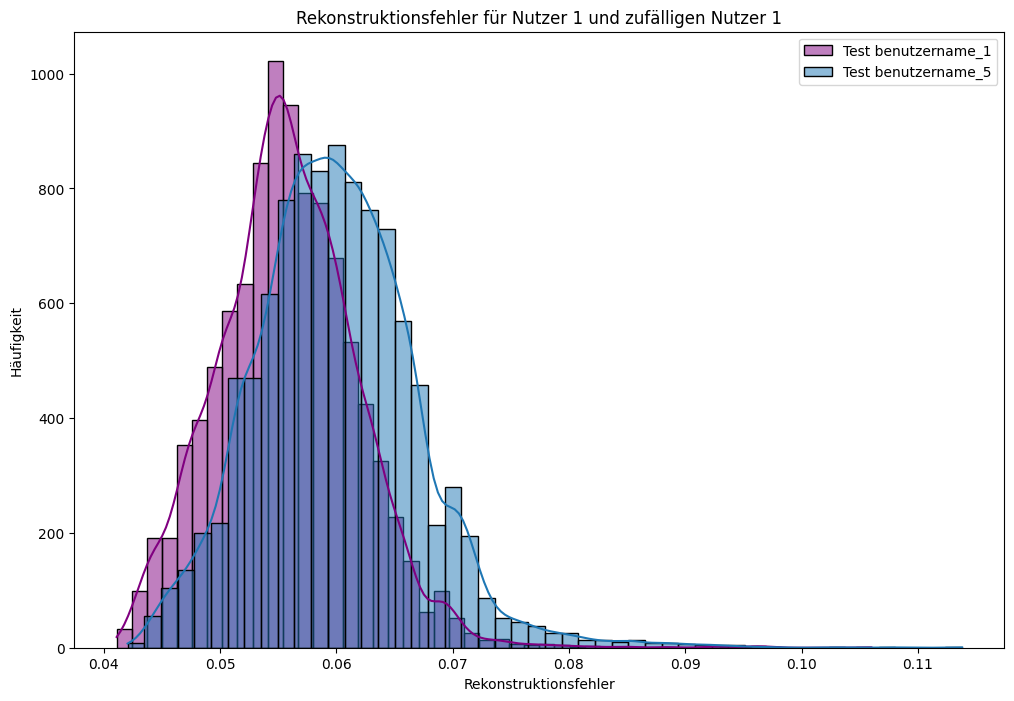

1/1 [==============================] - 0s 12ms/step


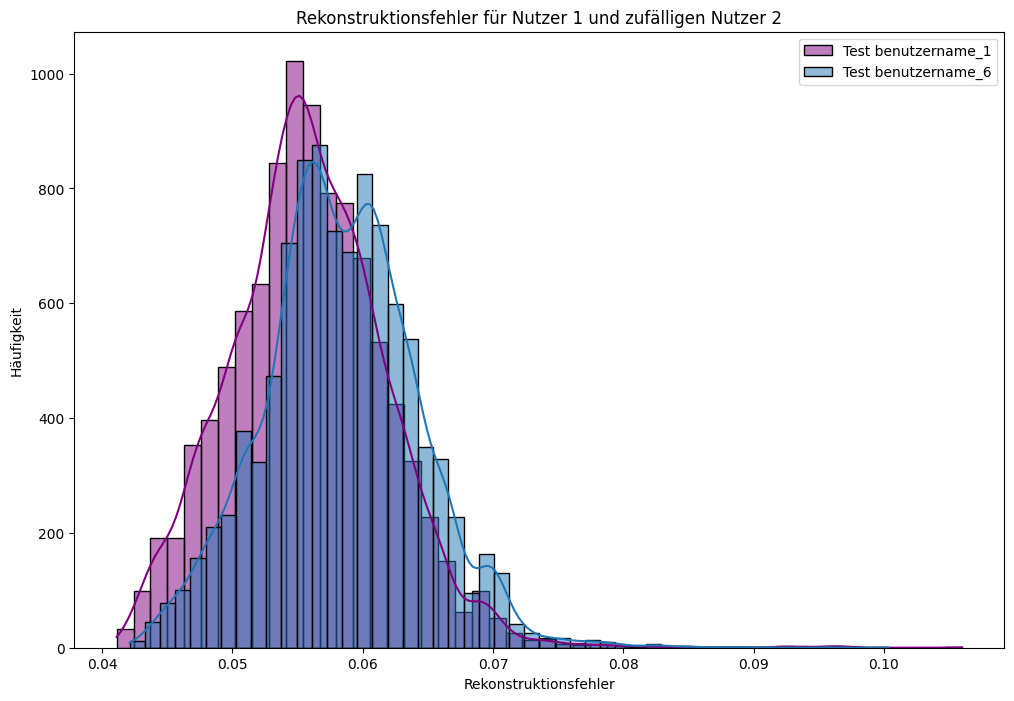

1/1 [==============================] - 0s 13ms/step


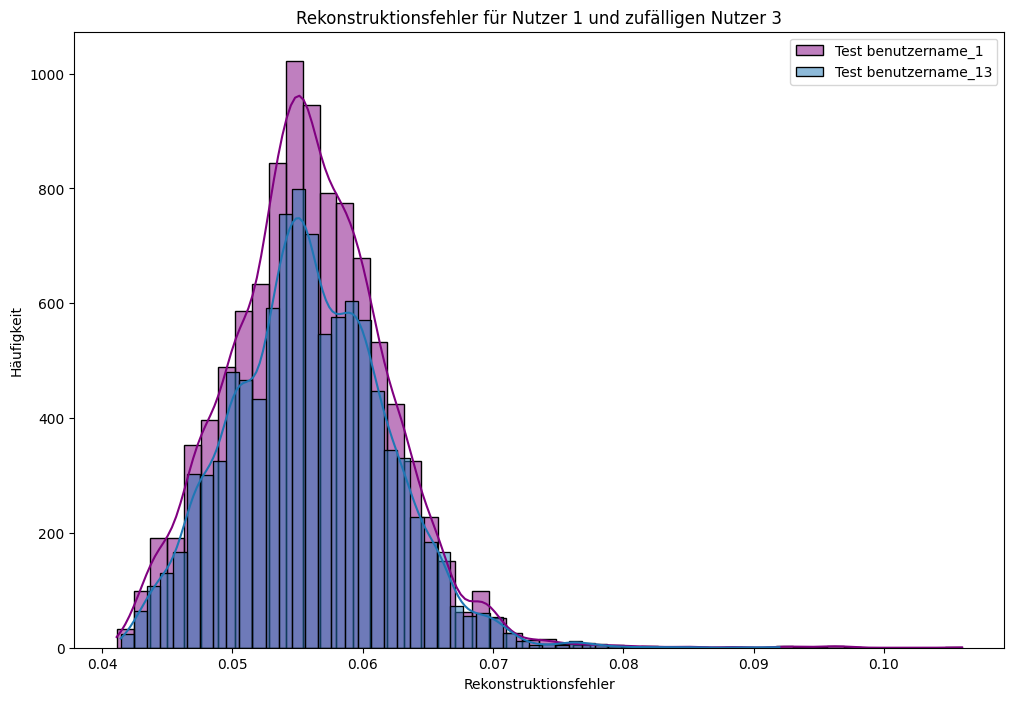

1/1 [==============================] - 0s 12ms/step


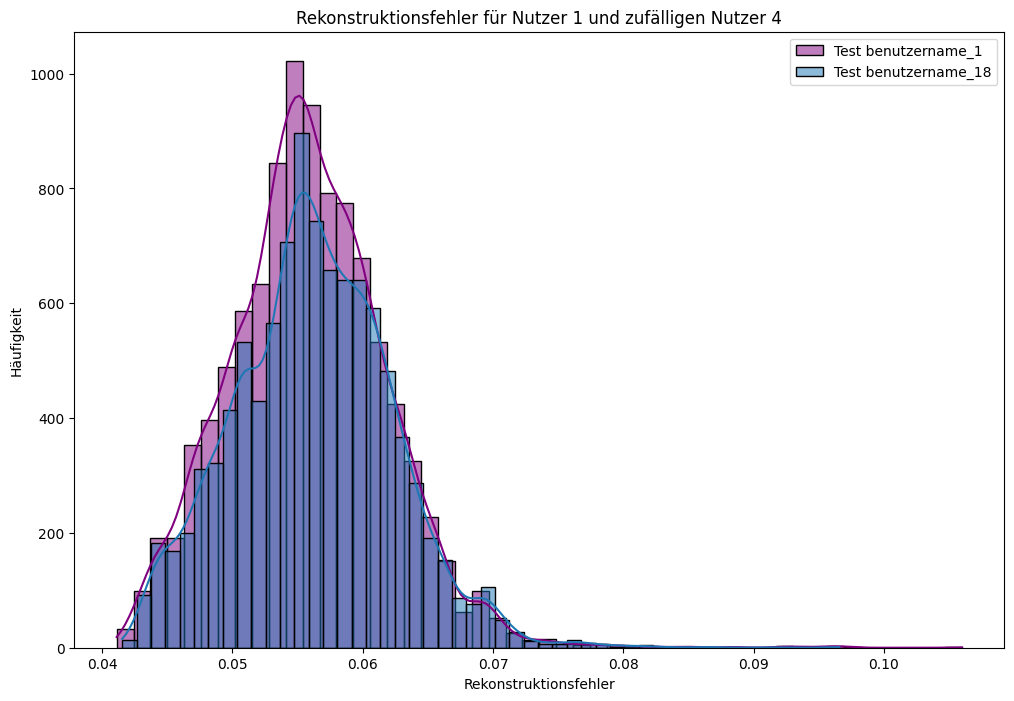

1/1 [==============================] - 0s 13ms/step


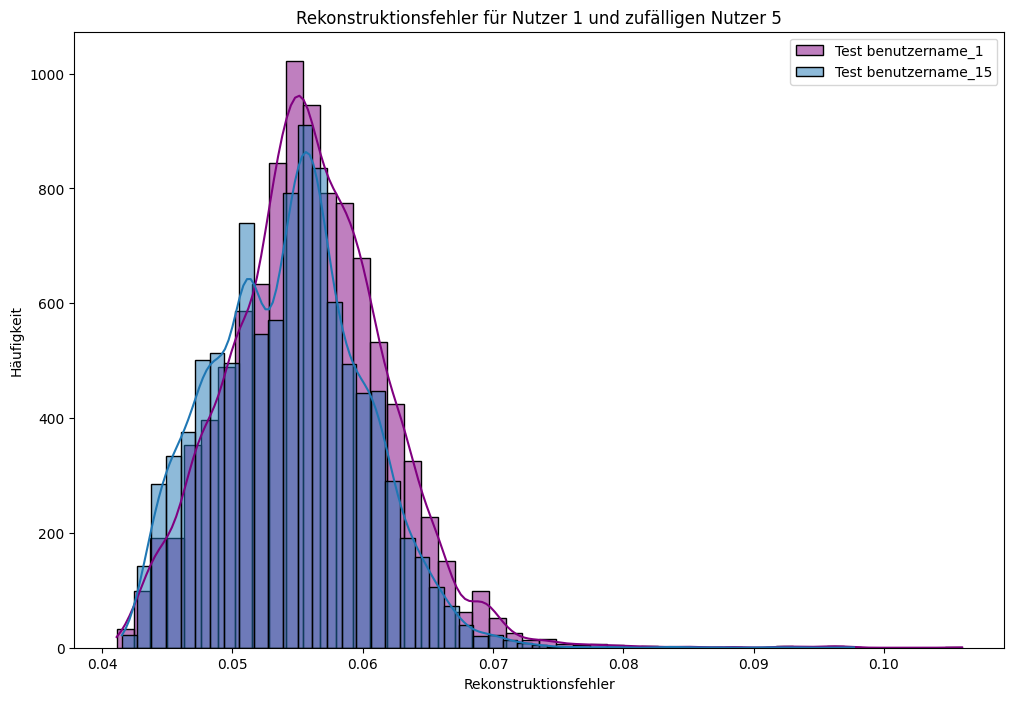

1/1 [==============================] - 0s 12ms/step

Bewertung der Modellleistung:
Durchschnittlicher Rekonstruktionsfehler (Nutzer 1): 0.05581683365917581
Durchschnittlicher Rekonstruktionsfehler (zufällige Nutzer): 0.05762750602184054

Adaptive Erklärung der Ergebnisse:
Das Modell erkennt Nutzer 1 einigermaßen gut, aber es gibt Raum für Verbesserungen.


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, generator):
    reconstruction_errors = []
    for batch in generator:
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
    return np.array(reconstruction_errors)

# Berechnung der Rekonstruktionsfehler für eine begrenzte Anzahl von Testdaten
def calculate_reconstruction_error_limited(model, generator, limit=10000):
    reconstruction_errors = []
    count = 0
    for batch in generator:
        if count >= limit:
            break
        X, _ = batch
        reconstructed = model.predict(X)
        reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
        reconstruction_errors.extend(reconstruction_error)
        count += len(X)
    return np.array(reconstruction_errors[:limit])

# Rekonstruktionsfehler für Nutzer 1
user_1_id = user_ids[0]  # Assuming user 1 is the first user in the list
_, _, test_generator_user_1 = user_generators[user_1_id]
reconstruction_error_user_1 = calculate_reconstruction_error_limited(autoencoder, test_generator_user_1, limit=10000)

# Erstellen von 5 Diagrammen mit Nutzer 1 und einem zufälligen anderen Nutzer
for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=10000)
    
    plt.figure(figsize=(12, 8))
    sns.histplot(reconstruction_error_user_1, bins=50, kde=True, color='purple', label=f'Test {user_1_id}')
    sns.histplot(reconstruction_error_random_user, bins=50, kde=True, label=f'Test {random_user_id}')
    
    plt.title(f'Rekonstruktionsfehler für Nutzer 1 und zufälligen Nutzer {i+1}')
    plt.xlabel('Rekonstruktionsfehler')
    plt.ylabel('Häufigkeit')
    plt.legend()
    plt.show()

# Bewertung der Modellleistung
mean_user_1_error = np.mean(reconstruction_error_user_1)
mean_random_user_errors = []

for i in range(5):
    random_user_id = random.choice([uid for uid in user_ids if uid != user_1_id])
    _, _, test_generator_random_user = user_generators[random_user_id]
    reconstruction_error_random_user = calculate_reconstruction_error_limited(autoencoder, test_generator_random_user, limit=10000)
    mean_random_user_errors.append(np.mean(reconstruction_error_random_user))

mean_random_user_error = np.mean(mean_random_user_errors)

print("\nBewertung der Modellleistung:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1): {mean_user_1_error}")
print(f"Durchschnittlicher Rekonstruktionsfehler (zufällige Nutzer): {mean_random_user_error}")

# Adaptive Erklärung der Ergebnisse
print("\nAdaptive Erklärung der Ergebnisse:")
if mean_user_1_error < min(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 gut und unterscheidet ihn von anderen Nutzern.")
elif mean_user_1_error < np.mean(mean_random_user_errors):
    print("Das Modell erkennt Nutzer 1 einigermaßen gut, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Test mit 10.000 zufälligen Samples pro Nutzer
random_samples = []
random_labels = []

for _ in range(10000 * len(user_ids)):
    random_user_id = random.choice(user_ids)
    _, _, test_generator_random_user = user_generators[random_user_id]
    random_sample = next(iter(test_generator_random_user))[0][0]  # Nimm das erste Sample aus dem Generator
    random_samples.append(random_sample)
    random_labels.append(1 if random_user_id == user_1_id else 0)

random_samples = np.array(random_samples)
reconstruction_errors_random_samples = np.mean(np.square(random_samples - autoencoder.predict(random_samples)), axis=1)

# Debugging-Ausgaben
print(f"Anzahl der zufälligen Samples: {len(random_samples)}")
print(f"Rekonstruktionsfehler für zufällige Samples: {reconstruction_errors_random_samples}")

# Grafische Darstellung der Rekonstruktionsfehler für zufällige Samples
plt.figure(figsize=(12, 8))
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 1], bins=50, kde=True, color='purple', label='Nutzer 1')
sns.histplot(reconstruction_errors_random_samples[np.array(random_labels) == 0], bins=50, kde=True, color='blue', label='Andere Nutzer')

plt.title('Rekonstruktionsfehler für zufällige Samples')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

# Bewertung der Modellleistung für zufällige Samples
mean_error_user_1_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 1])
mean_error_other_samples = np.mean(reconstruction_errors_random_samples[np.array(random_labels) == 0])

print("\nBewertung der Modellleistung für zufällige Samples:")
print(f"Durchschnittlicher Rekonstruktionsfehler (Nutzer 1 Samples): {mean_error_user_1_samples}")
print(f"Durchschnittlicher Rekonstruktionsfehler (Andere Nutzer Samples): {mean_error_other_samples}")

# Adaptive Erklärung der Ergebnisse für zufällige Samples
print("\nAdaptive Erklärung der Ergebnisse für zufällige Samples:")
if mean_error_user_1_samples < mean_error_other_samples:
    print("Das Modell erkennt zufällige Samples von Nutzer 1 gut und unterscheidet sie von anderen Nutzern.")
else:
    print("Das Modell hat Schwierigkeiten, zufällige Samples von Nutzer 1 von anderen Nutzern zu unterscheiden. Eine weitere Optimierung ist erforderlich.")

# Entscheidung, ob ein Sample als Nutzer 1 erkannt wird
threshold = (mean_error_user_1_samples + mean_error_other_samples) / 2
predictions = reconstruction_errors_random_samples < threshold

# Bewertung der Vorhersagen
true_positives = np.sum((predictions == 1) & (np.array(random_labels) == 1))
true_negatives = np.sum((predictions == 0) & (np.array(random_labels) == 0))
false_positives = np.sum((predictions == 1) & (np.array(random_labels) == 0))
false_negatives = np.sum((predictions == 0) & (np.array(random_labels) == 1))

print("\nVorhersageergebnisse:")
print(f"True Positives: {true_positives}")
print(f"True Negatives: {true_negatives}")
print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")

accuracy = (true_positives + true_negatives) / len(predictions)
print(f"Genauigkeit: {accuracy}")

# Adaptive Erklärung der Vorhersageergebnisse
print("\nAdaptive Erklärung der Vorhersageergebnisse:")
if accuracy > 0.8:
    print("Das Modell kann Nutzer 1 gut erkennen.")
elif accuracy > 0.6:
    print("Das Modell kann Nutzer 1 einigermaßen gut erkennen, aber es gibt Raum für Verbesserungen.")
else:
    print("Das Modell hat Schwierigkeiten, Nutzer 1 zu erkennen. Eine weitere Optimierung ist erforderlich.")

In [12]:
# Berechnung der Rekonstruktionsfehler
def calculate_reconstruction_error(model, X):
    reconstructed = model.predict(X)
    reconstruction_error = np.mean(np.square(X - reconstructed), axis=1)
    return reconstruction_error

# Rekonstruktionsfehler für den Trainings-, Validierungs- und Test-Satz des Benutzers
reconstruction_error_train = calculate_reconstruction_error(autoencoder, X_train)
reconstruction_error_val = calculate_reconstruction_error(autoencoder, X_val)
reconstruction_error_test = calculate_reconstruction_error(autoencoder, X_test)

# Rekonstruktionsfehler für die Test-Sätze anderer Benutzer
other_user_errors = {}
for other_user_id in user_ids:
    if other_user_id != user_id:
        _, _, X_test_other = user_splits[other_user_id]
        other_user_errors[other_user_id] = calculate_reconstruction_error(autoencoder, X_test_other)

# Grafische Darstellung der Ergebnisse
plt.figure(figsize=(12, 8))
sns.histplot(reconstruction_error_train, bins=50, kde=True, color='blue', label='Train')
sns.histplot(reconstruction_error_val, bins=50, kde=True, color='green', label='Validation')
sns.histplot(reconstruction_error_test, bins=50, kde=True, color='red', label='Test')

for other_user_id, errors in other_user_errors.items():
    sns.histplot(errors, bins=50, kde=True, label=f'Test {other_user_id}')

plt.title('Rekonstruktionsfehler')
plt.xlabel('Rekonstruktionsfehler')
plt.ylabel('Häufigkeit')
plt.legend()
plt.show()

NameError: name 'X_train' is not defined

In [ ]:
# Zusammenfassung der Ergebnisse
print("Rekonstruktionsfehler für den Trainingssatz:")
print(reconstruction_error_train.describe())

print("Rekonstruktionsfehler für den Validierungssatz:")
print(reconstruction_error_val.describe())

print("Rekonstruktionsfehler für den Testsatz:")
print(reconstruction_error_test.describe())

for other_user_id, errors in other_user_errors.items():
    print(f"Rekonstruktionsfehler für den Testsatz von Benutzer {other_user_id}:")
    print(errors.describe())